# 07 — SHAP Explainability

A hospital can't act on a black-box "72% risk" score. This notebook produces (1) global importance — what drives readmission risk across the population, and (2) local explanations — why one specific patient was flagged. Uses the XGBoost model from `06_model_evaluation.ipynb`.

## A real methodological problem, and the fix

The first version of this analysis produced global importance dominated by things like a `discharge_disposition_id` level with 21 training rows, and a `nateglinide=Up` level with 24. Tree models can fit noise to categorical levels with almost no support, and SHAP faithfully reports how much the (overfit, unreliable) model relies on them — so the ranking was meaningless. Fixed with `RareCategoryCollapser` in `src/transformers.py`: categories below a training-fold count threshold are merged into that column's *mode* (not a fresh small "Other" bucket, which would just relocate the same problem — a few medication columns have Up+Down summing to well under 100 rows even pooled). Fit on train only, inside the pipeline, to avoid leakage. The ranking below is what survives that fix.

In [1]:
import sys
sys.path.insert(0, '../src')
import joblib
import matplotlib.pyplot as plt
from explainability import get_shap_values, global_importance, explain_patient

pipe = joblib.load('../data/processed/models/xgboost.joblib')
X_train, X_test, y_train, y_test = joblib.load('../data/processed/models/splits.joblib')

explainer, shap_values, X_transformed_df, X_sample = get_shap_values(pipe, X_test, sample_size=2000)
imp = global_importance(shap_values, X_transformed_df.columns, top_n=15)
imp

C:\Users\CG\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,feature,mean_abs_shap
0,num__number_inpatient,0.222845
1,cat__discharge_disposition_id_1,0.161217
2,num__prior_utilization,0.069694
3,cat__payer_code_Unknown,0.062755
4,num__number_diagnoses,0.061242
5,num__age_midpoint,0.048367
6,num__prior_inpatient_flag,0.045793
7,cat__diag_1_group_Circulatory,0.043470
8,num__medication_complexity,0.040608
9,cat__diabetesMed_No,0.039283


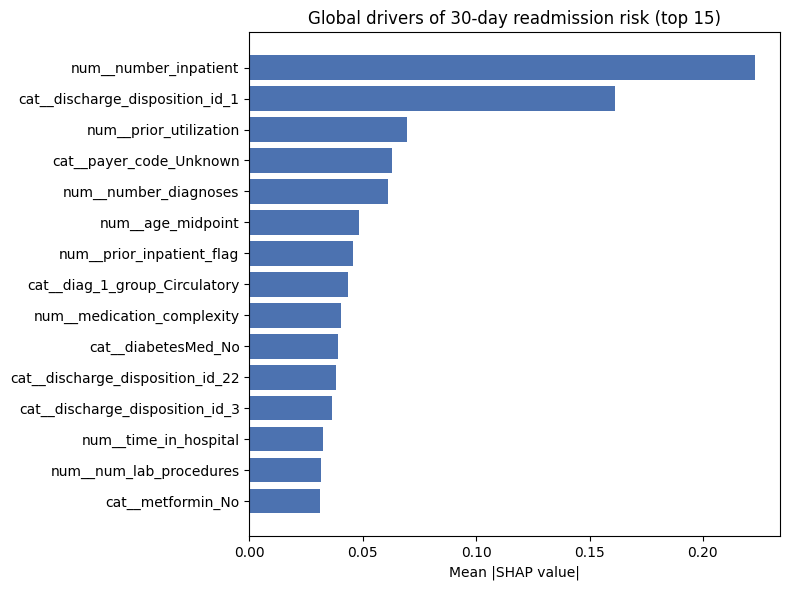

In [2]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(imp['feature'][::-1], imp['mean_abs_shap'][::-1], color='#4C72B0')
ax.set_xlabel('Mean |SHAP value|')
ax.set_title('Global drivers of 30-day readmission risk (top 15)')
plt.tight_layout()
plt.show()

**This ranking matches the earlier statistical and EDA findings closely** — prior inpatient visits (`number_inpatient`) is the dominant driver, followed by discharge disposition, prior utilization broadly, number of diagnoses, age, and comorbidity/medication signals. That agreement across three independent methods (EDA correlation, logistic regression odds ratios, SHAP) is a good sign the model is picking up real signal rather than an artifact.

## Local explanation — why was one specific patient flagged?

In [3]:
import numpy as np
proba_sample = pipe.predict_proba(X_sample)[:, 1]
high_risk_idx = int(np.argmax(proba_sample))
print(f'Patient at row {high_risk_idx}: predicted risk = {proba_sample[high_risk_idx]:.1%}')

local = explain_patient(explainer, shap_values, X_transformed_df, row_idx=high_risk_idx, top_n=8)
local

Patient at row 1073: predicted risk = 90.7%


,feature,value,shap_contribution
6,num__number_inpatient,6.560430,1.258753
110,cat__diag_2_group_Neoplasms,1.000000,0.261139
9,num__prior_utilization,3.752420,0.255162
79,cat__medical_specialty_Oncology,1.000000,0.243486
120,cat__diag_3_group_Neoplasms,1.000000,0.137598
11,num__prior_inpatient_flag,1.413604,0.095723
134,cat__diabetesMed_No,1.000000,-0.082988
68,cat__payer_code_Unknown,0.000000,-0.048143


Positive `shap_contribution` pushes predicted risk up, negative pushes it down — this is the level of explanation that goes into the per-patient view of the Streamlit app (`app/streamlit_app.py`), so a care-management team sees *why* a patient was flagged, not just a number.